# Ottimizzazione delle prestazioni di una rete neurale per il settore food

## Introduzione
**GourmetAI Inc.**, una rinomata azienda nel settore della tecnologia alimentare, si trova ad affrontare sfide crescenti nel migliorare l'accuratezza e l'efficienza dei sistemi di classificazione delle immagini di cibo. La necessità di fornire ai clienti soluzioni avanzate e di alta qualità per identificare e categorizzare correttamente i cibi è essenziale per migliorare l'esperienza utente e ottimizzare i processi aziendali.

---

## Benefici del Progetto
L'implementazione di tecniche avanzate di deep learning per la classificazione delle immagini di cibo offre numerosi vantaggi:

- **Miglioramento dell'Esperienza Utente**: Un sistema preciso e affidabile migliora significativamente l'esperienza degli utenti nelle applicazioni di riconoscimento di immagini di cibo, fornendo risultati rapidi e accurati.
- **Ottimizzazione dei Processi Aziendali**: Automatizzare la classificazione delle immagini riduce il tempo e le risorse necessarie per identificare e categorizzare i cibi, migliorando l'efficienza operativa complessiva.
- **Innovazione Tecnologica**: Utilizzare tecniche avanzate di deep learning promuove l'innovazione all'interno dell'azienda, consentendo di affrontare sfide complesse nel settore del riconoscimento delle immagini.
- **Obiettivi di Business**: Migliorare le performance dei modelli di classificazione aiuta GourmetAI Inc. a soddisfare gli obiettivi di business, consolidando la propria posizione come leader nel settore della tecnologia alimentare.

---

## Dettagli del Progetto
GourmetAI Inc. ha richiesto lo sviluppo di un modello avanzato di classificazione di immagini di cibo utilizzando tecniche di deep learning. Il progetto si baserà sul dataset **Food Classification**, arricchito con tecniche di augmentation per migliorare la diversità e la qualità dei dati disponibili.

### Obiettivi del Progetto
1. **Strategie di Augmentation**: Implementare diverse tecniche di augmentation per arricchire il dataset, migliorando la variabilità e la qualità dei dati.
2. **Divisione del Dataset**: Suddividere il dataset in trainset, valset e testset per garantire un'adeguata formazione e validazione del modello.
3. **Architetture di Rete e Transfer Learning**: Selezionare e implementare una o più architetture di rete neurale adatte al problema, utilizzando il transfer learning per sfruttare modelli pre-addestrati.
4. **Fine Tuning e Scelta degli Hyperparameters**: Creare un classificatore personalizzato, scegliere gli hyperparameters e ottimizzare il modello attraverso processi di training e validation.
5. **Validation e Regolarizzazione**: Utilizzare tecniche di validation per migliorare la scelta degli hyperparameters e risolvere potenziali problemi con tecniche di regolarizzazione.
6. **Test Finale**: Eseguire un test finale per verificare le capacità di generalizzazione del modello e raggiungere le performance desiderate.

---

## Fasi del Progetto
1. **Sviluppo delle Strategie di Augmentation**: Esplorazione e implementazione di tecniche di augmentation per arricchire il dataset.
2. **Preparazione del Dataset**: Divisione del dataset in trainset, valset e testset; preparazione degli strumenti per l'utilizzo delle immagini come input.
3. **Selezione e Implementazione delle Architetture**: Scelta e implementazione di architetture di rete neurale, applicando il transfer learning.
4. **Fine Tuning e Scelta degli Hyperparameters**: Creazione di un classificatore personalizzato, selezione degli hyperparameters e ottimizzazione del modello.
5. **Validation e Regolarizzazione**: Ripetizione del training con tecniche di validation e regolarizzazione per migliorare le performance del modello.
6. **Test Finale**: Esecuzione di un test finale per valutare le capacità di generalizzazione del modello e confrontare i risultati con le aspettative.

---

## Motivazione del Progetto
Per GourmetAI Inc., la precisione nella classificazione delle immagini di cibo rappresenta un requisito fondamentale. Migliorare l'efficacia dei sistemi di classificazione non solo migliora l'esperienza utente e ottimizza i processi aziendali, ma consente anche di consolidare la leadership nel settore della tecnologia alimentare attraverso l'innovazione tecnologica.

Con questo progetto, GourmetAI Inc. mira a sviluppare e implementare un sistema avanzato di classificazione di immagini di cibo, utilizzando tecniche all'avanguardia di deep learning per raggiungere performance superiori e soddisfare le esigenze specifiche del mercato.

---

## Dataset
Il dataset è disponibile al seguente link: [Food Classification Dataset](https://proai-datasets.s3.eu-west-3.amazonaws.com/dataset_food_classification.zip)

# Implementazione

In [1]:
%pip install --quiet torch torchvision torchmetrics albumentations numpy matplotlib seaborn pandas scikit-learn requests torchsummary

Note: you may need to restart the kernel to use updated packages.


In [2]:
#Dependencies import

# Standard library 
import os
import requests
import zipfile

#PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F

import torchvision
from torchvision.models import resnet50, ResNet50_Weights
from torchsummary import summary

#Albumentations
import albumentations as A
from albumentations.pytorch import ToTensorV2

#Metrics
from sklearn.metrics import classification_report, confusion_matrix

#Data management and compute
import numpy as np

#DNNHelper
from dnnhelper import Helper, EarlyStopping, Experiment, CrossValidation, Trainer

In [3]:
#DNNHelper module download

url = "https://raw.githubusercontent.com/crypto-infinity/proai/refs/heads/course6-pytorch/course6-pytorch/dnnhelper/__init__.py"
directory = "./dnnhelper"
file_path = os.path.join(directory, "__init__.py")

if not os.path.exists(directory):
    os.makedirs("./dnnhelper", exist_ok = True)
    response = requests.get(url)

    if response.status_code == 200:
        with open(file_path, "wb") as file:
            file.write(response.content)
        from dnnhelper import Experiment, EarlyStopping
    else:
        raise Exception(f"Errore durante il download del file: {response.status_code}")

In [4]:
#Dataset download and extraction

url = "https://proai-datasets.s3.eu-west-3.amazonaws.com/dataset_food_classification.zip"
directory = "./dataset"
file_path = os.path.join(directory, "food_classification.zip")
directory_to_extract_to = "./dataset/food_classification"

if not os.path.exists(directory_to_extract_to):
    os.makedirs("./dataset", exist_ok = True)
    response = requests.get(url)
    if response.status_code == 200:
        with open(file_path, "wb") as file:
            file.write(response.content)
            with zipfile.ZipFile(file_path, 'r') as zip_ref:
                zip_ref.extractall(directory_to_extract_to)
    else:
        raise Exception(f"Errore durante il download del file: {response.status_code}")

In [5]:
#PyTorch device setup

device = Helper.set_device()
print(f"Using device: {device}")

Using device: cpu


In [6]:
#Random seed for reproducibility

seed = 56

Helper.set_seed(seed)
print(f"Random seed set to: {seed}")

Random seed set to: 56


In [7]:
# Wrapper for Albumentations transforms

class Transforms:
    def __init__(self, transforms):
        self.transforms = transforms

    def __call__(self, img, *args, **kwargs):
        return self.transforms(image=np.array(img))['image']

# Import del dataset

## Analisi per data augmentation

In [8]:
# Preprocessing default template

default_preprocessing_pipeline = A.Compose([
            A.Resize(256, 256),
            A.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
            ToTensorV2(),
        ])

Motivazione: Le distorsioni geometriche aiutano il modello a generalizzare meglio, rendendolo più robusto a variazioni di prospettiva o deformazioni nelle immagini.

Motivazione: Le variazioni cromatiche migliorano la capacità del modello di adattarsi a condizioni di illuminazione diverse, come luci artificiali o naturali.

Motivazione: L'aggiunta di sfocature e rumore rende il modello più robusto a immagini di bassa qualità, come quelle scattate con dispositivi meno performanti.

In [9]:
# Data augmentation
# We avoid using every augmentation that scales/crops the image to avoid any information loss

augmentations = []

augmentations.append(
    #Geometric transformations
    A.Compose([
        A.Resize(256, 256),

        A.RandomRotate90(p=0.5),  #Light shifts, scaling and rotation
        A.OpticalDistortion(distort_limit=0.1, p=0.5),

        A.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
        ToTensorV2(),
    ])
)

augmentations.append(
    #Color transformations
    A.Compose([
        A.Resize(256, 256),

        A.HueSaturationValue(hue_shift_limit=20, sat_shift_limit=30, val_shift_limit=20, p=0.5), #Tone and color shift
        A.RGBShift(r_shift_limit=20, g_shift_limit=20, b_shift_limit=20, p=0.5), #RGB shift

        A.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
        ToTensorV2(),
    ])
)

augmentations.append(
    #Noise transformations
    A.Compose([
        A.Resize(256, 256),

        A.GaussianBlur(blur_limit=(3, 5), p=0.3),  # Gaussian blur and noise
        A.GaussNoise(std_range=(0.1, 0.2), p=0.3), 

        A.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
        ToTensorV2(),
    ])
)

In [10]:
final_augmentation = A.Compose([
    A.Resize(256, 256),

    A.RandomRotate90(p=0.5),  #Light shifts, scaling and rotation
    A.HueSaturationValue(hue_shift_limit=20, sat_shift_limit=30, val_shift_limit=20, p=0.5), #Tone and color shift
    A.GaussianBlur(blur_limit=(3, 5), p=0.3),

    A.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    ToTensorV2(),
])

In [11]:
#Dataset creation

trainset_path = './dataset/food_classification/dataset/train/'
valset_path = './dataset/food_classification/dataset/val/'
testset_path = './dataset/food_classification/dataset/test/'

testset = torchvision.datasets.ImageFolder(root=testset_path)

Struttura del dataset: ['test', 'train', 'val']
Classi: ['apple_pie', 'Baked Potato', 'cheesecake', 'chicken_curry', 'Crispy Chicken', 'Donut', 'Fries', 'Hot Dog', 'ice_cream', 'omelette', 'Sandwich', 'sushi', 'Taco', 'Taquito']


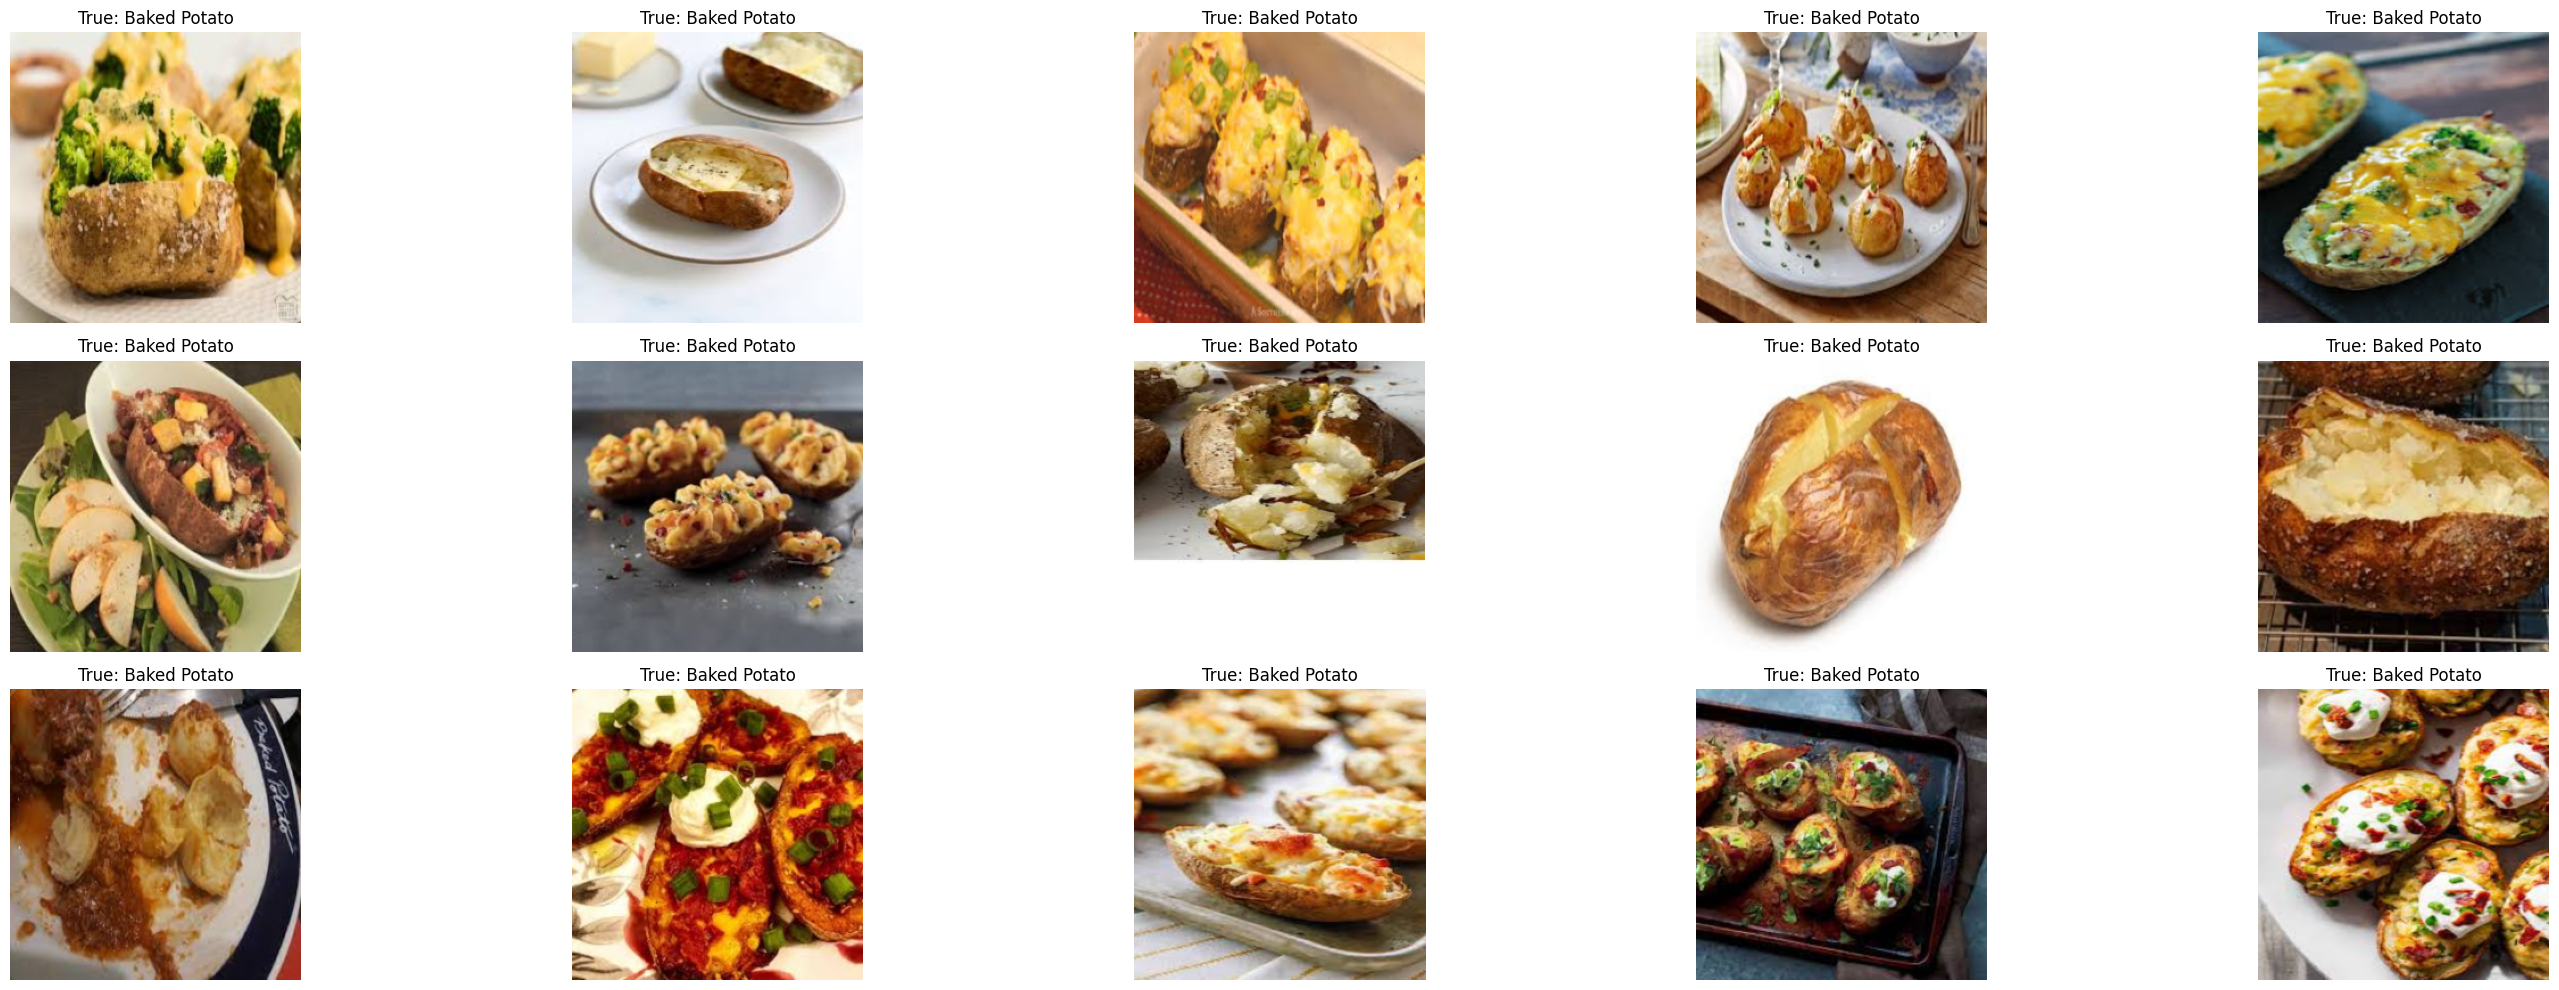

In [14]:
#First data exploration

print(f"Struttura del dataset: {os.listdir('./dataset/food_classification/dataset')}")
print(f"Classi: {os.listdir('./dataset/food_classification/dataset/train')}")

testset_defaultaug = testset
testset_defaultaug.transform = Transforms(default_preprocessing_pipeline)

Helper.plot_images(testset_defaultaug, testset.classes, 0)

del testset_defaultaug

In [ ]:
# Data augmentation application and exploration

for aug in augmentations:
    print(f"Applying augmentation: {aug}")

    # Apply the augmentation
    test_ds_aug = testset
    test_ds_aug.transform = Transforms(aug)

    # Plot the augmented images
    Helper.plot_images(test_ds_aug, test_ds_aug.classes, 5, num_row=4, num_col=5)

    del test_ds_aug

In [ ]:
# Data augmentation finalization

# We choose the best augmentation based on the previous exploration

trainset = torchvision.datasets.ImageFolder(root=trainset_path, transform=Transforms(final_augmentation))
valset = torchvision.datasets.ImageFolder(root=valset_path, transform=Transforms(final_augmentation))
testset.transform = Transforms(final_augmentation)

In [ ]:
Helper.plot_images(trainset, trainset.classes, 76)
Helper.plot_images(valset, valset.classes, 76)
Helper.plot_images(testset, testset.classes, 76)

In [ ]:
n_samples_train = len(trainset)
n_samples_val = len(valset)
n_samples_test = len(testset)

print(f"Training samples: {n_samples_train}")
print(f"Validation samples: {n_samples_val}")
print(f"Test samples: {n_samples_test}")

## Analisi della distribuzione delle classi

In [ ]:
classes = trainset.classes
n_classes = len(classes)

print(f"Classes: {classes}")
print(f"Number of classes: {n_classes}")

In [ ]:
Helper.plot_class_distribution(trainset, type="test")
Helper.plot_class_distribution(valset, type="test")
Helper.plot_class_distribution(testset, type="test")

Possiamo considerare conclusa la nostra fase esplorativa. Passiamo dunque alla definizione delle nostre strutture di reti neurali convoluzionali.

## Definizione delle reti

### Creazione della backbone ResNet

Definiamo ora la struttura delle nostre reti, sfruttando il transfer learning.

Data l'innovazione portata dalla struttura ResNet50 (https://arxiv.org/abs/1512.03385) nell'evitare il vanishing gradient, sfrutteremo le sue capacità di feature extraction, con i pesi di ImageNet.

Sotto istanzieremo la classe base, resnet:

In [ ]:
# Transfer Learning with ResNet50

resnet = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2).to(device)

# Freeze all layers
for param in resnet.parameters():
    param.requires_grad = False

### Creazione del classificatore custom

Ed ora creiamo i nostri classificatori custom, con i layer densi necessari alla classificazione delle nostre 14 classi.

Ne creiamo due differenti: la prima, senza regolarizzazione nella parte densa, e la seconda integrando Dropout e BatchNorm nel classificatore:

In [ ]:
class BaselineClassifier(nn.Module):
    """
    Baseline convolutional classifier using ResNet50 as backbone.
    """

    def __init__(self, resnet_backbone, in_features, n_classes):
        super().__init__()

        #backbone
        self.features = nn.Sequential(*list(resnet_backbone.children())[:-2])

        #fine-tuning
        self.pooling = nn.AdaptiveAvgPool2d((1,1))
        self.fc1 = nn.Linear(in_features, 1024)
        self.fc2 = nn.Linear(1024, n_classes)

    def forward(self, x):

        x = self.features(x) #[N, 2048, 8, 8]
        x = self.pooling(x) #[N, 2048, 1, 1]
        x = torch.flatten(x, 1) #[N, 2048]

        x = F.relu(self.fc1(x)) #[N, 1024]
        x = self.fc2(x) #[N, 14]

        return x

In [ ]:
class RegolarizedClassifier(nn.Module):
    """
    Regularized (in the classifier part) convolutional classifier using ResNet50 as backbone.
    """

    def __init__(self, resnet_backbone, in_features, n_classes):
        super().__init__()

        #backbone
        self.features = nn.Sequential(*list(resnet_backbone.children())[:-2])

        #fine-tuning
        self.pooling = nn.AdaptiveAvgPool2d((1,1))

        #Regularization
        self.dropout = nn.Dropout(p=0.5)
        self.norm = nn.BatchNorm1d(in_features)

        #linear
        self.fc1 = nn.Linear(in_features, 2048)
        self.fc2 = nn.Linear(2048, n_classes)

    def forward(self, x):

        x = self.features(x) #[N, 2048, 8, 8]
        x = self.pooling(x) #[N, 2048, 1, 1]
        x = torch.flatten(x, 1) #[N, 2048]

        x = self.dropout(x) #[N, 2048] - avoids neurons co-adaptation
        x = F.relu(self.norm(x)) #[N, 2048] - normalizes the activations inputs

        x = F.relu(self.fc1(x)) #[N, 2048]
        x = self.dropout(x)
        x = self.fc2(x) #[N, 14]

        return x

Instanziamo le classi e visualizziamone la struttura:

In [ ]:
baseline = BaselineClassifier(resnet, 2048, n_classes).to(device)

summary(baseline, (3, 256, 256))

In [ ]:
regolarized = RegolarizedClassifier(resnet, 2048, n_classes).to(device)

summary(regolarized, (3, 256, 256))

## Training e tuning dei modelli

Arriviamo ora al training delle nostre reti. Cominciamo con il definire alcune strategie di ottimizzazione, descrivendo il processo di training e valutazione dei vari modelli.

### Hyperparameters tuning

Per l'ottimizzazione delle nostre reti sul task, agiremo sui seguenti iperparametri:

* Optimizer
* Learning Rate
* LR Decay
* Epoch number
* Early Stopping (con differenti patiences)

Inoltre, testeremo due strutture di reti differenti. La prima, senza regolarizzazione nei layer densi. La seconda con, in aggiunta:

* Dropout
* BatchNorm

Instanziamo quindi gli esperimenti (ci limiteremo a 4 esempi per evitare tempi di training troppo elevati):

In [ ]:
experiments = []

experiments.append(
    Experiment(
        name = "baseline",
        checkpoints_folder = 'models',
        checkpoint_name = "baseline.pt",
        model = baseline,
        n_classes = n_classes,
        metrics = ["accuracy", "precision"],
        use_early_stopping = True,
        loss_fn = nn.CrossEntropyLoss,
        optimizer = torch.optim.Adam,
        lr = 5e-4, 
        epochs = 20,
        patience = 5,
        color = "#2C15C4",
        alpha = .3,
    )
)

experiments.append(
    Experiment(
        name = "regolarized",
        checkpoints_folder = 'models',
        checkpoint_name = "regolarized.pt",
        model = regolarized,
        n_classes=n_classes,
        metrics = ["accuracy", "precision"],
        use_early_stopping = True,
        loss_fn = nn.CrossEntropyLoss,
        optimizer = torch.optim.Adam,
        lr = 1e-4,
        epochs = 40,
        patience= 5,
        color = "#23C4A4",
        alpha = .3,
    )
)

experiments.append(
    Experiment(
        name = "autolr_regolarized",
        checkpoints_folder = 'models',
        checkpoint_name = "autolr_adam.pt",
        model = regolarized,
        n_classes=n_classes,
        lr = 1e-4,
        lr_scheduler=True,
        lr_step=5,
        metrics = ["accuracy", "precision"],
        use_early_stopping = True,
        loss_fn = nn.CrossEntropyLoss,
        optimizer = torch.optim.Adam,
        epochs = 40,
        patience= 5,
        color = "#EB4310",
        alpha = .3,
    )
)

Ed istanziamo la nostra classe di Cross-Validation, che effettuerà automaticamente gli split, il training e l'evaluation dei vari esperimenti:

In [ ]:
cross_val = CrossValidation(
    experiments=experiments,
    train_ds=trainset,
    val_ds=valset,
    batch_size=64,
    n_splits=3, # we'll keep fold number low to avoid long training times
    verbose=True
)

Eseguiamo infine il processo:

In [ ]:
%%time
cross_val_results = cross_val.run()

In [ ]:
print(f"Risultati della cross-validation:\n {cross_val_results}")

Il Learning Rate sembra aver avuto un importante impatto sulle performance del training. Partendo da 1e-2, si è notato che il suo abbassamento ha prodotto notevoli miglioramenti. Inoltre, anche la profondità della rete ha influito. All'aggiunta di un ulteriore layer, la rete ha preso una condotta di discesa della loss che i suoi predecessori non avevano.

### Verifica dei risultati

Abbiamo già raccolto alcuni dati di risultati della cross-validation al punto sopra. A titolo di conferma, rieseguiamo il train degli esperimenti sull'intero trainset (senza splits), e valutiamone nuovamente le performances.

Definiamo quindi un metodo di valutazione, che calcolerà le nostre classi predette e mostrerà il classification report, la confusion matrix e la loss dei vari modelli:

In [ ]:
#experiments[0].model.load_state_dict(torch.load(experiments[0].checkpoints_folder + "\\" + experiments[0].checkpoint_name, map_location=device))

In [ ]:
# Classification report and confusion matrix

def evaluate_experiment(exp, dataset):
    """
    Evaluate the trained models on the test set and print classification reports and confusion matrices.
    """

    print(f"Classification report for {exp.name}:\n")

    loader = torch.utils.data.DataLoader(dataset, batch_size=32, shuffle=False)

    y_true = dataset.targets
    y_pred = Trainer.predict(exp, loader)
    
    print(classification_report(y_true, y_pred, target_names=classes))
    Helper.plot_confusion_matrix(y_true, y_pred, classes, title=f"Confusion Matrix for {exp.name}")
    Helper.plot_loss(exp)

    print("\n")

E avviamo il processo, ripristinando i pesi dei modelli e l'optimizer degli esperimenti prima di un nuovo training:

In [ ]:
# Reset the model to initial state

for exp in experiments:

    for i, layer in enumerate(exp.model.children()):
        if hasattr(layer, 'reset_parameters') and i >= 173: # Skip the ResNet backbone
            layer.reset_parameters()

    exp.optimizer = exp.optimizer.__class__(exp.model.parameters(), lr=exp.lr)

In [ ]:
for exp in experiments:
    # Train the model
    Trainer.fit(exp, trainset, valset, verbose=True)

In [ ]:
for exp in experiments:
    # Evaluate the model
    evaluate_experiment(exp, valset)

-integrare

### Check finale sul testset

Rieseguiamo infine le medesime valutazioni, questa volta sul testset, per ciascun esperimento:

In [ ]:
%%time

for exp in experiments:
    evaluate_experiment(exp, testset)

-integrare

## Commenti finali